In [1]:
cd ..

c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Import Packages


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Hyperparameters

In [44]:
num_epochs = 30
batch_size = 256
learning_rate = 0.001
latent_dim = 64
top_k = 5
num_layers = 3

# num_epochs = 25
# batch_size = 256
# learning_rate = 0.001
# latent_dim = 16
# top_k = 5
# num_layers = 8

In [45]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Dataset Preparation

In [46]:
class NCFDataset(Dataset):
    def __init__(self, user_ids, item_ids, ratings):
        self.user_ids = user_ids
        self.item_ids = item_ids
        self.ratings = ratings

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.user_ids[idx], self.item_ids[idx], self.ratings[idx]

In [47]:
# Load datasets
attraction_df = pd.read_csv('./Data/FinalDataset/Data.csv')
ratings_df = pd.read_csv('./Data/FinalDataset/ratings.csv')
ratings_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  2133 non-null   int64
 1   id       2133 non-null   int64
 2   rating   2133 non-null   int64
dtypes: int64(3)
memory usage: 50.1 KB


In [48]:
attraction_df.head()

,id,name,description,latitude,longitude,province,location,tags
0,1,Chapat Ganesh Mandir,Chapat Ganesh Temple is Ganesh temple located ...,27.671314,85.328967,Bagmati Province,Bagmati Province,"hindu, temple, pilgrimage"
1,2,Mayadevi Temple,Religious Site The Mayadevi temple is situated...,27.469641,83.275785,Lumbini Province,Lumbini Province,"buddhist, pilgrimage"
2,3,Sikali Mandir,Religious Site Sikali Temple lies in the south...,27.643535,85.285502,Bagmati Province,Kathmandu Valley,"hindu, temple, cultural"
3,4,Bala Guru Sadananda,Bala Guru Sadananda's shrine at his Ashram in ...,27.357001,87.137018,Koshi Province,Shadananda Municipality,"historical, monument"
4,5,21st Century Art Gallery,"21st Century Art Gallery, located in Kathmandu...",27.715548,85.309497,Bagmati Province,Kathmandu,"art_gallery, museum, cultural"


In [49]:

# Data preprocessing
ratings_df['id'] = ratings_df['id'].fillna(-1)
ratings_df = ratings_df.drop_duplicates(subset=['user_id', 'id'])

# Encode user_id and place_id
user_encoder = LabelEncoder()
place_encoder = LabelEncoder()
ratings_df['user_id'] = user_encoder.fit_transform(ratings_df['user_id'])
ratings_df['id'] = place_encoder.fit_transform(ratings_df['id'])

num_users = len(user_encoder.classes_)
num_items = len(place_encoder.classes_)
print(num_users, num_items)


1888 351


# Model Building

In [50]:

# class GMF(nn.Module):
#     def __init__(self, num_users, num_items, latent_dim):
#         super(GMF, self).__init__()
#         self.user_embedding = nn.Embedding(num_users, latent_dim)
#         self.item_embedding = nn.Embedding(num_items, latent_dim)
        
#         # Initialize embeddings properly
#         nn.init.normal_(self.user_embedding.weight, std=0.01)
#         nn.init.normal_(self.item_embedding.weight, std=0.01)

#     def forward(self, user_ids, item_ids):
#         user_emb = self.user_embedding(user_ids)
#         item_emb = self.item_embedding(item_ids)
#         return user_emb * item_emb

In [51]:

# class MLP(nn.Module):
#     def __init__(self, latent_dim, hidden_layers):
#         super(MLP, self).__init__()
#         input_dim = latent_dim * 2
        
#         layers = []
#         for i, units in enumerate(hidden_layers):
#             layers.append(nn.Linear(input_dim, units))
#             layers.append(nn.BatchNorm1d(units))
#             layers.append(nn.ReLU())
#             layers.append(nn.Dropout(p=0.3 if i == 0 else 0.2))
#             input_dim = units
            
#         self.mlp = nn.Sequential(*layers)
        
#         # Initialize weights properly
#         for layer in self.mlp:
#             if isinstance(layer, nn.Linear):
#                 nn.init.xavier_uniform_(layer.weight)
#                 nn.init.zeros_(layer.bias)

#     def forward(self, user_emb, item_emb):
#         x = torch.cat([user_emb, item_emb], dim=-1)
#         return self.mlp(x)

In [52]:
# import torch
# import torch.nn as nn

# class NCF(nn.Module):
#     def __init__(self, num_users, num_items, latent_dim=64, hidden_layers=[256, 128, 64], dropout_rate=0.4):
#         super(NCF, self).__init__()

#         self.gmf = GMF(num_users, num_items, latent_dim)  # Ensure GMF is implemented
#         self.mlp = MLP(latent_dim * 2, hidden_layers)  # Ensure MLP is implemented

#         # Separate embeddings for MLP
#         self.mlp_user_embedding = nn.Embedding(num_users, latent_dim)
#         self.mlp_item_embedding = nn.Embedding(num_items, latent_dim)

#         fusion_dim = latent_dim + hidden_layers[-1]
#         self.output_layer = nn.Sequential(
#             nn.Linear(fusion_dim, 32),
#             nn.ReLU(),
#             nn.Dropout(dropout_rate),
#             nn.Linear(32, 1)  # No activation here
#         )

#         self._init_weights()

#     def _init_weights(self):
#         for m in self.output_layer:
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_uniform_(m.weight)
#                 nn.init.zeros_(m.bias)

#     def forward(self, user_ids, item_ids):
#         # GMF path
#         gmf_output = self.gmf(user_ids, item_ids)

#         # MLP path with proper concatenation
#         mlp_user_emb = self.mlp_user_embedding(user_ids)
#         mlp_item_emb = self.mlp_item_embedding(item_ids)
#         mlp_input = torch.cat([mlp_user_emb, mlp_item_emb], dim=-1)
#         mlp_output = self.mlp(mlp_input)

#         # Combine GMF & MLP outputs
#         combined = torch.cat([gmf_output, mlp_output], dim=-1)
#         output = self.output_layer(combined)

#         return output  # No sigmoid activation for rating prediction

#     def predict(self, user_ids, item_ids):
#         with torch.no_grad():
#             return self(user_ids, item_ids)


In [53]:
import torch
import torch.nn as nn

class GMF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim):
        super(GMF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, latent_dim)
        self.item_embedding = nn.Embedding(num_items, latent_dim)

    def forward(self, user_ids, item_ids):
        user_emb = self.user_embedding(user_ids)
        item_emb = self.item_embedding(item_ids)
        return user_emb * item_emb  # Element-wise multiplication

class MLP(nn.Module):
    def __init__(self, num_users, num_items, latent_dim, hidden_layers):
        super(MLP, self).__init__()
        self.user_embedding = nn.Embedding(num_users, latent_dim)
        self.item_embedding = nn.Embedding(num_items, latent_dim)

        input_dim = latent_dim * 2  # Because we concatenate embeddings
        layers = []
        for layer_size in hidden_layers:
            layers.append(nn.Linear(input_dim, layer_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.4))
            input_dim = layer_size  # Update input for next layer

        self.mlp_layers = nn.Sequential(*layers)

    def forward(self, user_ids, item_ids):
        user_emb = self.user_embedding(user_ids)
        item_emb = self.item_embedding(item_ids)
        mlp_input = torch.cat([user_emb, item_emb], dim=-1)
        return self.mlp_layers(mlp_input)

class NCF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim=64, hidden_layers=[256, 128, 64]):
        super(NCF, self).__init__()
        self.gmf = GMF(num_users, num_items, latent_dim)
        self.mlp = MLP(num_users, num_items, latent_dim, hidden_layers)

        fusion_dim = latent_dim + hidden_layers[-1]
        self.output_layer = nn.Sequential(
            nn.Linear(fusion_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # No activation
        )

    def forward(self, user_ids, item_ids):
        gmf_output = self.gmf(user_ids, item_ids)
        mlp_output = self.mlp(user_ids, item_ids)

        combined = torch.cat([gmf_output, mlp_output], dim=-1)
        output = self.output_layer(combined)
        return output  # No sigmoid for rating prediction

    def predict(self, user_ids, item_ids):
        with torch.no_grad():
            return self(user_ids, item_ids)


In [54]:

# def evaluate_topn(model, test_loader, num_items, top_k):
#     """
#     Evaluate model performance using Hit Rate, NDCG@K, RMSE, Precision, and Recall.

#     Args:
#         model: The trained recommendation model
#         test_loader: DataLoader containing test data
#         num_items: Total number of items in the dataset
#         top_k: Number of top items to consider for evaluation

#     Returns:
#         tuple: (hit_rate, ndcg, rmse, precision, recall) metrics
#     """
#     device = next(model.parameters()).device
#     hits = []
#     ndcgs = []
#     squared_errors = []
#     precisions = []
#     recalls = []

#     top_k = min(top_k, num_items)
#     model.eval()

#     with torch.no_grad():
#         for user_ids, item_ids, ratings in test_loader:
#             user_ids = user_ids.to(device)
#             item_ids = item_ids.to(device)
#             ratings = ratings.to(device)

#             # Threshold for relevant items (adjust as needed)
#             relevant_threshold = ratings.mean().item()

#             # Get positive items (actual interactions)
#             positive_items = item_ids[ratings >= relevant_threshold].tolist()

#             if not positive_items:
#                 continue

#             # Generate predictions for all items for each user
#             all_item_ids = torch.arange(num_items).to(device)

#             # Handle each user in the batch separately
#             for user_id in user_ids:
#                 user_vector = user_id.repeat(num_items)
#                 predictions = model(user_vector, all_item_ids)
#                 predictions = predictions.squeeze()

#                 try:
#                     # Get top-k item predictions
#                     _, indices = torch.topk(predictions, k=top_k)
#                     recommended_items = indices.cpu().tolist()

#                     # Calculate Hit Rate
#                     hit = int(any(item in recommended_items for item in positive_items))
#                     hits.append(hit)

#                     # Calculate NDCG
#                     dcg = 0.0
#                     idcg = 1.0  # Ideal DCG for binary case with one positive item
#                     for idx, item in enumerate(recommended_items):
#                         if item in positive_items:
#                             dcg += 1.0 / np.log2(idx + 2)

#                         # Compute Ideal DCG
#                     # idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(positive_items), top_k)))
#                     ndcg = dcg / idcg
#                     ndcgs.append(ndcg)

#                     # Calculate Precision and Recall
#                     hit_items = set(recommended_items) & set(positive_items)
#                     precision = len(hit_items) / top_k if top_k > 0 else 0
#                     recall = len(hit_items) / len(positive_items) if positive_items else 0
#                     precisions.append(precision)
#                     recalls.append(recall)

#                     # Calculate squared errors for RMSE
#                     batch_predictions = model(user_ids, item_ids).squeeze()
#                     batch_se = (batch_predictions - ratings) ** 2
#                     squared_errors.extend(batch_se.cpu().tolist())

#                 except RuntimeError as e:
#                     print(f"Warning: Error processing predictions: {e}")
#                     continue

#     if not hits:
#         return 0.0, 0.0, 0.0, 0.0, 0.0

#     hit_rate = np.mean(hits)
#     mean_ndcg = np.mean(ndcgs)
#     rmse = np.sqrt(np.mean(squared_errors)) if squared_errors else 0.0
#     mean_precision = np.mean(precisions)
#     mean_recall = np.mean(recalls)

#     return hit_rate, mean_ndcg, rmse, mean_precision, mean_recall


In [65]:
def evaluate_topn(model, test_loader, num_items, top_k):
    """
    Evaluate model performance using Hit Rate, NDCG@K, RMSE, Precision, and Recall.
    
    Args:
        model: The trained recommendation model
        test_loader: DataLoader containing test data
        num_items: Total number of items in the dataset
        top_k: Number of top items to consider for evaluation
    
    Returns:
        tuple: (hit_rate, ndcg, rmse, precision, recall) metrics
    """
    device = next(model.parameters()).device
    hits = []
    ndcgs = []
    squared_errors = []
    precisions = []
    recalls = []
    
    top_k = min(top_k, num_items)
    model.eval()
    
    with torch.no_grad():
        for user_ids, item_ids, ratings in test_loader:
            user_ids = user_ids.to(device)
            item_ids = item_ids.to(device)
            ratings = ratings.to(device)
            
            # Get positive items (actual interactions)
            relevant_threshold = ratings.mean().item()
            positive_items = item_ids[ratings >= relevant_threshold].tolist()
            
            if not positive_items:
                continue
            
            # Generate predictions for all items for each user
            all_item_ids = torch.arange(num_items).to(device)
            
            # Handle each user in the batch separately
            for user_id in user_ids:
                user_vector = user_id.repeat(num_items)
                predictions = model(user_vector, all_item_ids)
                predictions = predictions.squeeze()
                
                try:
                    # Get top-k item predictions
                    _, indices = torch.topk(predictions, k=top_k)
                    recommended_items = indices.cpu().tolist()
                    
                    # Calculate Hit Rate
                    hit = int(any(item in recommended_items for item in positive_items))
                    hits.append(hit)
                    
                    # Calculate NDCG
                    dcg = 0.0
                    idcg = 1.0  # Ideal DCG for binary case with one positive item
                    for idx, item in enumerate(recommended_items):
                        if item in positive_items:
                            dcg += 1.0 / np.log2(idx + 2)
                    
                    ndcg = dcg / idcg
                    ndcgs.append(ndcg)
                    
                    # Calculate Precision and Recall
                    hit_items = set(recommended_items) & set(positive_items)
                    precision = len(hit_items) / top_k if top_k > 0 else 0
                    recall = len(hit_items) / len(positive_items) if positive_items else 0
                    precisions.append(precision)
                    recalls.append(recall)
                    
                    # Calculate squared errors for RMSE
                    batch_predictions = model(user_ids, item_ids).squeeze()
                    batch_se = (batch_predictions - ratings) ** 2
                    squared_errors.extend(batch_se.cpu().tolist())
                    
                except RuntimeError as e:
                    print(f"Warning: Error processing predictions: {e}")
                    continue
    
    # Return zeros if no hits were recorded
    if not hits:
        return 0.0, 0.0, 0.0, 0.0, 0.0
    
    # Calculate final metrics
    hit_rate = np.mean(hits)
    mean_ndcg = np.mean(ndcgs)
    rmse = np.sqrt(np.mean(squared_errors)) if squared_errors else 0.0
    mean_precision = np.mean(precisions)
    mean_recall = np.mean(recalls)
    
    return hit_rate, mean_ndcg, rmse, mean_precision, mean_recall

In [66]:
# Split into train and test by *users*
user_ids = ratings_df['user_id'].unique()
train_users, test_users = train_test_split(user_ids, test_size=0.3, random_state=30)

train_df = ratings_df[ratings_df['user_id'].isin(train_users)].copy()
test_df = ratings_df[ratings_df['user_id'].isin(test_users)].copy()



In [67]:
#  Convert split DataFrames to tensors
train_user_ids = torch.tensor(train_df['user_id'].values, dtype=torch.long)
train_item_ids = torch.tensor(train_df['id'].values, dtype=torch.long)
train_ratings = torch.tensor(train_df['rating'].values, dtype=torch.float32)

test_user_ids = torch.tensor(test_df['user_id'].values, dtype=torch.long)
test_item_ids = torch.tensor(test_df['id'].values, dtype=torch.long)
test_ratings = torch.tensor(test_df['rating'].values, dtype=torch.float32)


# Create dataset and dataloaders
train_dataset = NCFDataset(train_user_ids, train_item_ids, train_ratings)
test_dataset = NCFDataset(test_user_ids, test_item_ids, test_ratings)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Use the defined batch_size
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Use the defined batch_size


In [68]:
# Checking the distribution
print("\nTrain set statistics:")
print(train_ratings.float().mean())
print(train_ratings.float().std())
print(train_df['rating'].value_counts())

print("\nTest set statistics:")
print(test_ratings.float().mean())
print(test_ratings.float().std())
print(test_df['rating'].value_counts())

print("\nUnique users in train:", len(train_df['user_id'].unique()))
print("Unique users in test:", len(test_df['user_id'].unique()))
print("Unique items in train:", len(train_df['id'].unique()))
print("Unique items in test:", len(test_df['id'].unique()))


Train set statistics:
tensor(4.3126)
tensor(1.1872)
rating
5    948
4    286
3    122
1     52
2     36
0     34
Name: count, dtype: int64

Test set statistics:
tensor(4.3770)
tensor(1.0492)
rating
5    395
4    129
3     57
1     19
2     12
0      6
Name: count, dtype: int64

Unique users in train: 1321
Unique users in test: 567
Unique items in train: 339
Unique items in test: 270


In [69]:
# Check overlap
train_users_set = set(train_df['user_id'].unique())
test_users_set = set(test_df['user_id'].unique())
print("\nUsers only in test:", len(test_users_set - train_users_set))

train_items_set = set(train_df['id'].unique())
test_items_set = set(test_df['id'].unique())
print("Items only in test:", len(test_items_set - train_items_set))


Users only in test: 567
Items only in test: 12


In [70]:
# Initialize the model, loss function, and optimizer
hidden_layers = [2**(7 - i) for i in range(num_layers)]
model = NCF(num_users, num_items, latent_dim=16, hidden_layers=hidden_layers).to(device)
criterion = nn.MSELoss()  # Replace MSELoss

# optimizer = optim.Adam(model.parameters(), lr=learning_rate)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)


In [71]:
model

NCF(
  (gmf): GMF(
    (user_embedding): Embedding(1888, 16)
    (item_embedding): Embedding(351, 16)
  )
  (mlp): MLP(
    (user_embedding): Embedding(1888, 16)
    (item_embedding): Embedding(351, 16)
    (mlp_layers): Sequential(
      (0): Linear(in_features=32, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.4, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.4, inplace=False)
      (6): Linear(in_features=64, out_features=32, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.4, inplace=False)
    )
  )
  (output_layer): Sequential(
    (0): Linear(in_features=48, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [72]:
# num_epochs = 25
# batch_size = 256
# learning_rate = 0.001
# latent_dim = 16
# top_k = 5
# num_layers = 8

In [73]:
# Lists to store training and test loss for each epoch
train_losses = []
test_losses = []

# Lists to track Hit Rate, NDCG and RMSE for all epochs
hit_rates, ndcgs ,rmses, precisions, recalls, maes= [], [], [], [], [], []


best_hit_rate = 0.0
best_ndcg = 0.0
best_rmse = float('inf')  # Initialize to infinity for RMSE
best_mae = float('inf') # Initialize to infinity for MAE
best_epoch = -1
best_precision = 0.0
best_recall = 0.0
# Training loop with progress bar
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    # Wrap train_loader with tqdm for progress bar
    for user_ids, item_ids, ratings in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        user_ids, item_ids, ratings = user_ids.to(device), item_ids.to(device), ratings.to(device)
        
        optimizer.zero_grad()
        predictions = model(user_ids, item_ids)
        loss = criterion(predictions.squeeze(), ratings)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Evaluation phase
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        mae_sum = 0.0  # Sum of absolute errors for MAE
        total_samples = 0  # Total number of samples for MAE
        for user_ids, item_ids, ratings in test_loader:
            user_ids, item_ids, ratings = user_ids.to(device), item_ids.to(device), ratings.to(device)
            predictions = model(user_ids, item_ids)
            loss = criterion(predictions.squeeze(), ratings)
            test_loss += loss.item()

            # MAE calculation
            mae_sum += torch.sum(torch.abs(predictions.squeeze() - ratings)).item()
            total_samples += len(ratings)
        
        avg_test_loss = test_loss / len(test_loader)
        avg_mae = mae_sum / total_samples  # Calculate MAE
        test_losses.append(avg_test_loss)
        maes.append(avg_mae)
    
    # Calculate evaluation metrics
    hit_rate, ndcg, rmse, precision, recall = evaluate_topn(model, test_loader, num_items, top_k)
    
    # Store metrics
    hit_rates.append(hit_rate)
    ndcgs.append(ndcg)
    rmses.append(rmse)
    precisions.append(precision)
    recalls.append(recall)
    
    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Training Loss: {avg_train_loss:.4f}, "
          f"Test Loss: {avg_test_loss:.4f}, "
          f"MAE: {avg_mae:.4f}, "
          f"Hit Rate@{top_k}: {hit_rate:.4f}, "
          f"NDCG@{top_k}: {ndcg:.4f}, "
          f"RMSE: {rmse:.4f}, "
          f"Precision@{top_k}: {precision:.4f}, "
          f"Recall@{top_k}: {recall:.4f}")
    
    # Update best metrics
    if hit_rate > best_hit_rate:
        best_hit_rate = hit_rate
        best_ndcg = ndcg
        best_rmse = rmse
        best_mae = avg_mae
        best_precision = precision
        best_recall = recall
        best_epoch = epoch
    elif hit_rate == best_hit_rate and ndcg > best_ndcg:
        best_ndcg = ndcg
        best_rmse = rmse
        best_mae = avg_mae
        best_precision = precision
        best_recall = recall
        best_epoch = epoch

# Print best metrics
print(f"\n\nBest Epoch: {best_epoch + 1}")
print(f"Hit Rate@{top_k}: {best_hit_rate:.4f}")
print(f"NDCG@{top_k}: {best_ndcg:.4f}")
print(f"RMSE: {best_rmse:.4f}")
print(f"MAE: {best_mae:.4f}")
print(f"Precision@{top_k}: {best_precision:.4f}")
print(f"Recall@{top_k}: {best_recall:.4f}")

Epoch 1/30: 100%|██████████| 6/6 [00:00<00:00, 47.35it/s]


Epoch 1/30, Training Loss: 18.5822, Test Loss: 18.1303, MAE: 4.1527, Hit Rate@5: 0.7751, NDCG@5: 0.7481, RMSE: 4.2915, Precision@5: 0.2547, Recall@5: 0.0088


Epoch 2/30: 100%|██████████| 6/6 [00:00<00:00, 129.79it/s]


Epoch 2/30, Training Loss: 17.2462, Test Loss: 16.4347, MAE: 3.9459, Hit Rate@5: 0.7767, NDCG@5: 0.7161, RMSE: 4.0874, Precision@5: 0.2443, Recall@5: 0.0087


Epoch 3/30: 100%|██████████| 6/6 [00:00<00:00, 169.47it/s]


...

Epoch 28/30, Training Loss: 2.1021, Test Loss: 1.6184, MAE: 1.0709, Hit Rate@5: 0.7848, NDCG@5: 0.7373, RMSE: 1.2480, Precision@5: 0.2537, Recall@5: 0.0081


Epoch 29/30: 100%|██████████| 6/6 [00:00<00:00, 143.98it/s]


Epoch 29/30, Training Loss: 1.9293, Test Loss: 1.5095, MAE: 1.0056, Hit Rate@5: 0.7864, NDCG@5: 0.7473, RMSE: 1.1971, Precision@5: 0.2547, Recall@5: 0.0081


Epoch 30/30: 100%|██████████| 6/6 [00:00<00:00, 131.88it/s]


Epoch 30/30, Training Loss: 2.0206, Test Loss: 1.4297, MAE: 0.9440, Hit Rate@5: 0.7913, NDCG@5: 0.7457, RMSE: 1.1560, Precision@5: 0.2550, Recall@5: 0.0082


Best Epoch: 13
Hit Rate@5: 0.8479
NDCG@5: 0.9517
RMSE: 1.2709
MAE: 1.0924
Precision@5: 0.3045
Recall@5: 0.0098


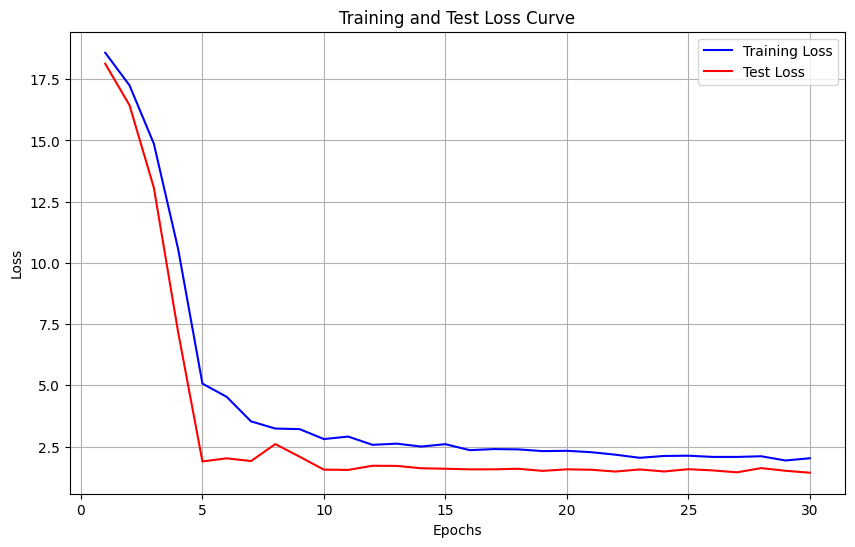

In [74]:
# Plotting the training and test loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss", color="blue")
plt.plot(range(1, num_epochs+1), test_losses, label="Test Loss", color="red")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

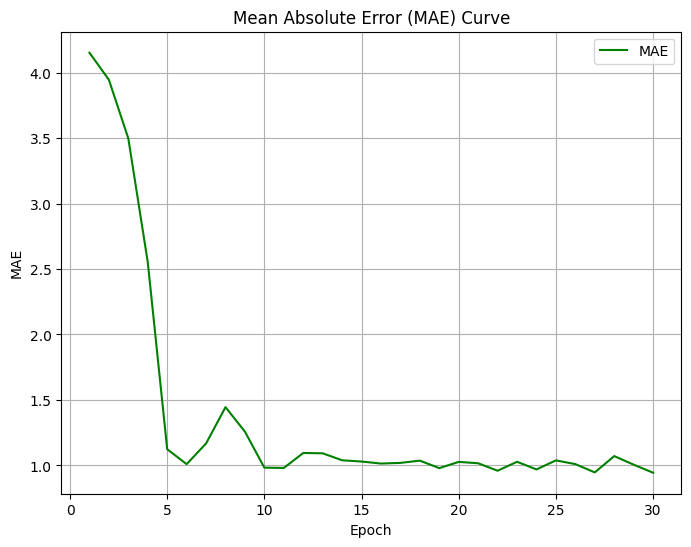

In [75]:
# Plot MAE curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), maes, label='MAE', color='green')
plt.title('Mean Absolute Error (MAE) Curve')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid()
# plt.savefig('mae_curve.png')  # Save the graph
# plt.show()

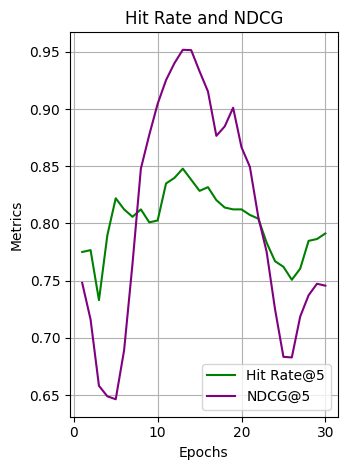

In [76]:
# Plotting Hit Rate and NDCG
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), hit_rates, label=f"Hit Rate@{top_k}", color="green")
plt.plot(range(1, num_epochs + 1), ndcgs, label=f"NDCG@{top_k}", color="purple")
plt.xlabel("Epochs")
plt.ylabel("Metrics")
plt.title("Hit Rate and NDCG")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [77]:
# calculate average of all metrics
hit_rate_avg = np.mean(hit_rates)
ndcg_avg = np.mean(ndcgs)
rmse_avg = np.mean(rmses)
precision_avg = np.mean(precisions)
recall_avg = np.mean(recalls)
mae_avg = np.mean(maes)
print(f"Average Hit Rate@{top_k}: {hit_rate_avg:.4f}")
print(f"Average NDCG@{top_k}: {ndcg_avg:.4f}")
print(f"Average RMSE: {rmse_avg:.4f}")
print(f"Average MAE: {mae_avg:.4f}")
print(f"Average Precision@{top_k}: {precision_avg:.4f}")
print(f"Average Recall@{top_k}: {recall_avg:.4f}")


Average Hit Rate@5: 0.8003
Average NDCG@5: 0.8039
Average RMSE: 1.5726
Average MAE: 1.3811
Average Precision@5: 0.2670
Average Recall@5: 0.0089


In [180]:
def generate_recommendations_with_rating(model, user_id, num_items, top_k, device, place_encoder, attraction_df, min_score=0.5):
    """
    Generates top-K recommendations for a user with confidence scores.
    """
    model.eval()
    with torch.no_grad():
        user_vector = torch.tensor([user_id], dtype=torch.long).repeat(num_items).to(device)
        all_item_ids = torch.arange(num_items, dtype=torch.long).to(device)
        
        # Get predictions and confidence scores
        predictions = model(user_vector, all_item_ids).squeeze()
        scores, indices = torch.topk(predictions, k=min(top_k * 2, num_items))
        
        # Filter by minimum confidence score
        mask = scores >= min_score
        filtered_indices = indices[mask][:top_k]
        filtered_scores = scores[mask][:top_k]
        
        recommended_items = filtered_indices.cpu().tolist()
        confidence_scores = filtered_scores.cpu().tolist()
        
        # Process recommendations
        recommendations = []
        for item_id, score in zip(recommended_items, confidence_scores):
            try:
                original_item_id = place_encoder.inverse_transform([item_id])[0]
                attraction = attraction_df.loc[attraction_df['id'] == original_item_id]
                
                if not attraction.empty:
                    item_name = attraction['name'].iloc[0]
                    item_details = {
                        'id': original_item_id,
                        'name': item_name,
                        'confidence': round(float(score), 3)
                    }
                    
                    # Add additional details if available
                    for col in ['category', 'rating', 'location']:
                        if col in attraction.columns:
                            item_details[col] = attraction[col].iloc[0]
                            
                    recommendations.append(item_details)
                
            except Exception as e:
                print(f"Error processing item {item_id}: {str(e)}")
                continue
                
        return recommendations[:top_k]

In [181]:
def generate_recommendations(
    model, user_id, num_items, top_k, device, place_encoder, attraction_df, user_item_matrix, min_score=0.5
):
    """
    Generates top-K recommendations for a user, excluding rated items, with confidence scores.
    """
    model.eval()
    with torch.no_grad():
        # Retrieve items rated by the user
        rated_item_ids = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index.tolist())

        user_vector = torch.tensor([user_id], dtype=torch.long).repeat(num_items).to(device)
        all_item_ids = torch.arange(num_items, dtype=torch.long).to(device)

        # Get predictions and confidence scores
        predictions = model(user_vector, all_item_ids).squeeze()

        # Exclude items the user has rated
        filtered_predictions = [
            (item_id, score.item())
            for item_id, score in enumerate(predictions)
            if item_id not in rated_item_ids
        ]

        # Sort by prediction score and select top-K
        filtered_predictions.sort(key=lambda x: x[1], reverse=True)
        top_predictions = filtered_predictions[:top_k]

        # Extract the indices and scores
        recommended_items = [item[0] for item in top_predictions if item[1] >= min_score]
        confidence_scores = [item[1] for item in top_predictions if item[1] >= min_score]

        # Process recommendations
        recommendations = []
        for item_id, score in zip(recommended_items, confidence_scores):
            try:
                original_item_id = place_encoder.inverse_transform([item_id])[0]
                attraction = attraction_df.loc[attraction_df['id'] == original_item_id]

                if not attraction.empty:
                    item_name = attraction['name'].iloc[0]
                    item_details = {
                        "id": original_item_id,
                        "name": item_name,
                        "confidence": round(float(score), 3),
                    }

                    # Add additional details if available
                    for col in ["category", "rating", "location"]:
                        if col in attraction.columns:
                            item_details[col] = attraction[col].iloc[0]

                    recommendations.append(item_details)

            except Exception as e:
                print(f"Error processing item {item_id}: {str(e)}")
                continue

        return recommendations[:top_k]


In [182]:
# Example usage
# Example usage
original_user_id = 150# Change this to your desired user from ratings_final.csv

# Encode the user ID using the user_encoder
encoded_user_id = user_encoder.transform([original_user_id])[0]
print(encoded_user_id)
recommendations = generate_recommendations_with_rating(model, encoded_user_id, num_items, top_k, device, place_encoder, attraction_df)
# print(recommendations)
# print(f"Top {top_k} recommendations for user {original_user_id}:")
# for item_id, item_name in recommendations:
  # print(f"   - Encoded Item ID: {item_id}, Attraction Name: {item_name}")
# Display recommendations in a readable format
print("Top Recommended Places:")
for idx, rec in enumerate(recommendations, 1):
    print(f"{idx}. {rec['name']} (ID: {rec['id']})")
    print(f"   - Confidence: {rec['confidence']}")
    print(f"   - Location: {rec['location']}\n")

143
Top Recommended Places:
1. Atelier 2 Fine Art Gallery (ID: 99)
   - Confidence: 5.007
   - Location: Dallu Aawas Marg

2. Chame View Point (ID: 358)
   - Confidence: 4.972
   - Location: baesaiisahara - chaamae sadaka

3. Bhootnath Mahadev Temple (ID: 261)
   - Confidence: 4.914
   - Location: Janakpur

4. Dangisharan Cultural Homestay (ID: 508)
   - Confidence: 4.908
   - Location: Dangisharan-4, Baibang

5. Bhairabsthan Temple (ID: 205)
   - Confidence: 4.733
   - Location: Tansen-Palpa District

